In [49]:
# Twitter Sentiment Analysis
### Natural Language Processing Project

**Goal:** Classify tweets as Positive or Negative using Machine Learning

**Dataset:** Sentiment140 — 1.6 million labeled tweets

**Models used:**
- Baseline: Logistic Regression + TF-IDF (Accuracy: 77.84%)
- Upgraded: BERT fine-tuning (coming next)

**Project structure:**
- `notebooks/` — this notebook with full analysis and visualizations
- `models/` — saved trained models
- `data/` — dataset and prediction exports
- `app/` — Streamlit web app (coming next)

**Results summary:**
| Model | Accuracy | AUC |
|-------|----------|-----|
| Logistic Regression | 77.84% | ~0.86 |
| BERT (fine-tuned) | TBD | TBD |

SyntaxError: invalid character '—' (U+2014) (2249791770.py, line 6)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\venne\AppData\Roaming\nltk_data...


All libraries imported successfully!


[nltk_data]   Unzipping corpora\stopwords.zip.


In [3]:
cols = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df = pd.read_csv(
    '../data/training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    names=cols
)

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (1600000, 6)
   sentiment          id                          date     query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [5]:
df = df[['sentiment', 'text']]
df['sentiment'] = df['sentiment'].replace(4, 1)

print(df['sentiment'].value_counts())
print(df.head())

sentiment
0    800000
1    800000
Name: count, dtype: int64
   sentiment                                               text
0          0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1          0  is upset that he can't update his Facebook by ...
2          0  @Kenichan I dived many times for the ball. Man...
3          0    my whole body feels itchy and like its on fire 
4          0  @nationwideclass no, it's not behaving at all....


C:\Users\venne\AppData\Local\Temp\ipykernel_25604\2100178286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette=['#E24B4A', '#1D9E75'])


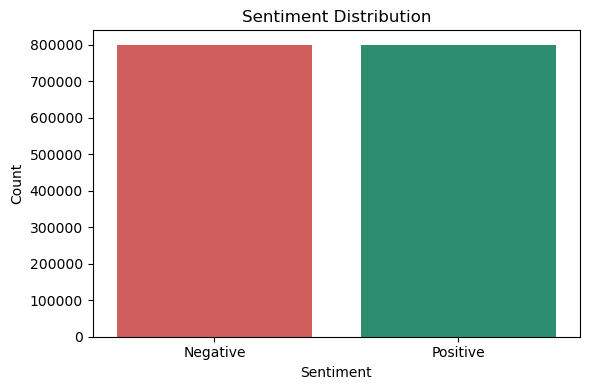

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette=['#E24B4A', '#1D9E75'])
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()

In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'http\S+', '', text)       
    text = re.sub(r'@\w+', '', text)          
    text = re.sub(r'#\w+', '', text)           
    text = re.sub(r'[^a-zA-Z\s]', '', text)   
    text = text.lower().strip()                 
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

print(clean_text("I love @elonmusk!! Check this out: https://twitter.com #amazing 😊"))

love check


In [11]:
print("Cleaning tweets... this will take 3-5 minutes")
df['clean_text'] = df['text'].apply(clean_text)
print("Done!")
print(df[['text', 'clean_text']].head(3))

Cleaning tweets... this will take 3-5 minutes
Done!
                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   

                                          clean_text  
0  awww thats bummer shoulda got david carr third...  
1  upset cant update facebook texting might cry r...  
2  dived many times ball managed save rest go bounds  


In [13]:
df_sample = df.sample(n=200000, random_state=42)
print(f"Sample size: {df_sample.shape}")
print(df_sample['sentiment'].value_counts())

Sample size: (200000, 3)
sentiment
1    100143
0     99857
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

X = df_sample['clean_text']
y = df_sample['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 160000
Testing samples:  40000


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (160000, 50000)


In [19]:
from sklearn.linear_model import LogisticRegression
import time

print("Training model...")
start = time.time()

model_lr = LogisticRegression(max_iter=1000, C=1.0)
model_lr.fit(X_train_tfidf, y_train)

end = time.time()
print(f"Training done in {round(end - start, 1)} seconds")

Training model...
Training done in 1.4 seconds


In [21]:
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)

y_pred = model_lr.predict(X_test_tfidf)
y_prob = model_lr.predict_proba(X_test_tfidf)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {acc:.4f}  ({round(acc*100, 2)}%)")
print(f"AUC Score: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Positive']))

Accuracy : 0.7784  (77.84%)
AUC Score: 0.8607

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.76      0.78     20088
    Positive       0.77      0.80      0.78     19912

    accuracy                           0.78     40000
   macro avg       0.78      0.78      0.78     40000
weighted avg       0.78      0.78      0.78     40000



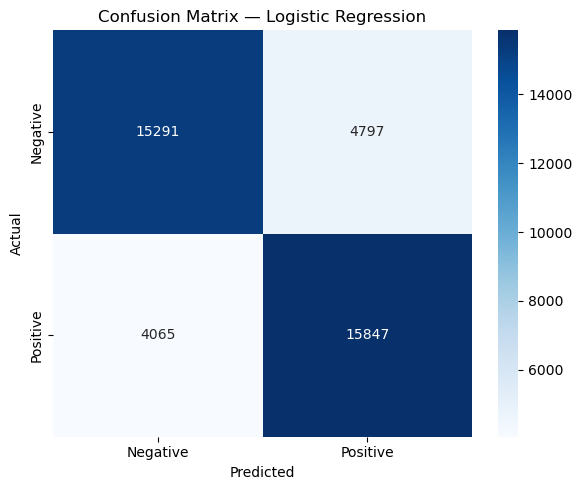

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150)
plt.show()

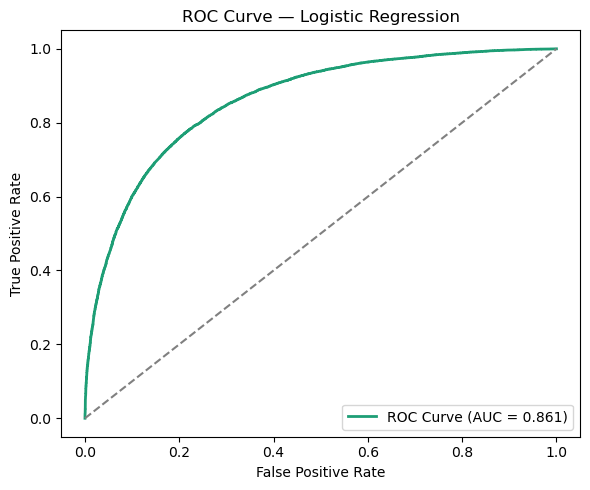

In [25]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#1D9E75', lw=2,
         label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_lr.png', dpi=150)
plt.show()

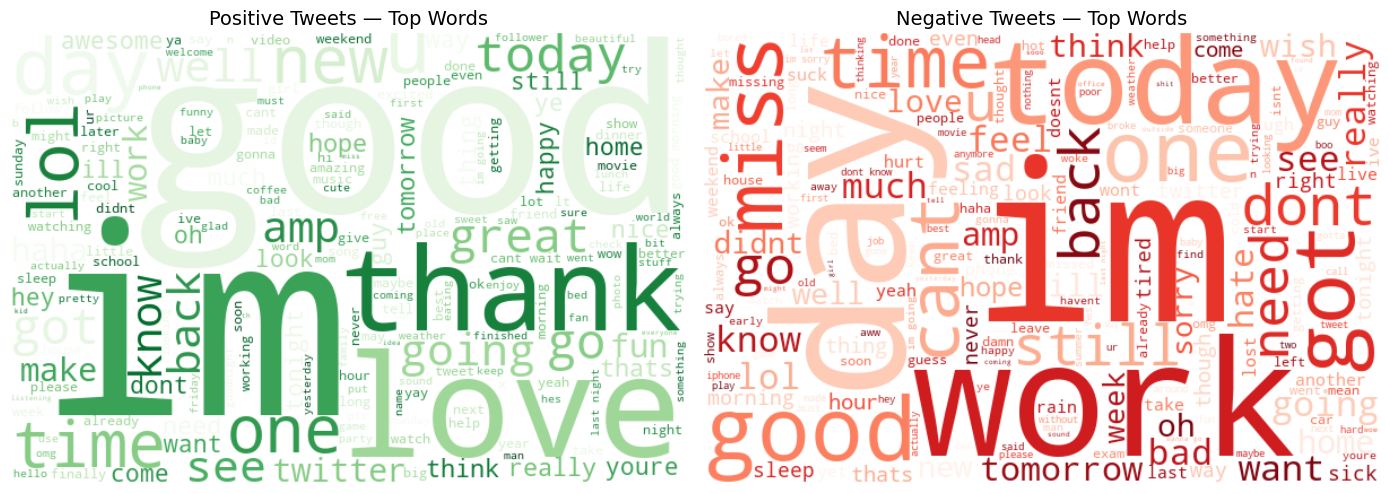

In [31]:
positive_words = ' '.join(
    df_sample[df_sample['sentiment'] == 1]['clean_text'].sample(5000))
negative_words = ' '.join(
    df_sample[df_sample['sentiment'] == 0]['clean_text'].sample(5000))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_pos = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap='Greens').generate(positive_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Tweets — Top Words', fontsize=14)

wc_neg = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap='Reds').generate(negative_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Tweets — Top Words', fontsize=14)

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

In [33]:
import joblib

joblib.dump(model_lr, '../models/logistic_regression_model.pkl')
joblib.dump(tfidf,    '../models/tfidf_vectorizer.pkl')

print("Model and vectorizer saved to /models folder!")

Model and vectorizer saved to /models folder!


In [57]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model_lr.predict(vectorized)[0]
    confidence = model_lr.predict_proba(vectorized)[0]
    label = "Positive" if prediction == 1 else "Negative"
    conf_score = round(max(confidence) * 100, 2)
    print(f"Text      : {text}")
    print(f"Sentiment : {label}")
    print(f"Confidence: {conf_score}%")

predict_sentiment("aarohi is a girl")
predict_sentiment("This is the worst experience ever.")
predict_sentiment("The movie was okay, nothing special.")

Text      : aarohi is a girl
Sentiment : Positive
Confidence: 79.43%
Text      : This is the worst experience ever.
Sentiment : Negative
Confidence: 85.4%
Text      : The movie was okay, nothing special.
Sentiment : Positive
Confidence: 74.36%


In [45]:
df_export = df_sample.sample(n=10000, random_state=99).copy()

df_export_tfidf = tfidf.transform(df_export['clean_text'])
df_export['predicted_sentiment'] = model_lr.predict(df_export_tfidf)
df_export['confidence'] = model_lr.predict_proba(
    df_export_tfidf).max(axis=1).round(4)

df_export['sentiment_label'] = df_export['sentiment'].map(
    {0: 'Negative', 1: 'Positive'})
df_export['predicted_label'] = df_export['predicted_sentiment'].map(
    {0: 'Negative', 1: 'Positive'})
df_export['correct'] = (
    df_export['sentiment'] == df_export['predicted_sentiment'])

print(df_export[['text', 'sentiment_label',
                  'predicted_label', 'confidence', 'correct']].head(5))

                                                     text sentiment_label  \
297803  @ThomRainer good post on twitter! liked the pe...        Negative   
136885  @Jayme1988 I cant go to sleep till I know she ...        Negative   
221400  cavs. just need sum stops!! and refs need to c...        Negative   
775735  @shawnmayer hey how have you been?? it sucks i...        Negative   
289886                                           srsly...        Negative   

       predicted_label  confidence  correct  
297803        Negative      0.5955     True  
136885        Negative      0.9565     True  
221400        Negative      0.7648     True  
775735        Negative      0.9475     True  
289886        Negative      0.7187     True  


In [47]:
export_cols = ['text', 'clean_text', 'sentiment_label',
               'predicted_label', 'confidence', 'correct']

df_export[export_cols].to_csv(
    '../data/predictions_export.csv', index=False)

print("Exported! File saved to /data/predictions_export.csv")
print(f"Shape: {df_export.shape}")
print(f"\nAccuracy on export set: "
      f"{df_export['correct'].mean()*100:.2f}%")

Exported! File saved to /data/predictions_export.csv
Shape: (10000, 8)

Accuracy on export set: 81.10%
